Лабораторная работа 3:

Визуализация данных (Pandas, Matplotlib, Seaborn)

ФИО: Ушакова Марина Михайловна

Группа: ЕТ-212

0. Импорт библиотек и загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # для 3D-графика
import seaborn as sns
# Загрузка датафрейма
df = pd.read_csv('StudentsPerformance.csv')
# Быстрый просмотр
print(df.head())
print(df.info())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

1. Pandas

1.1 Столбчатая диаграмма для parental level of education

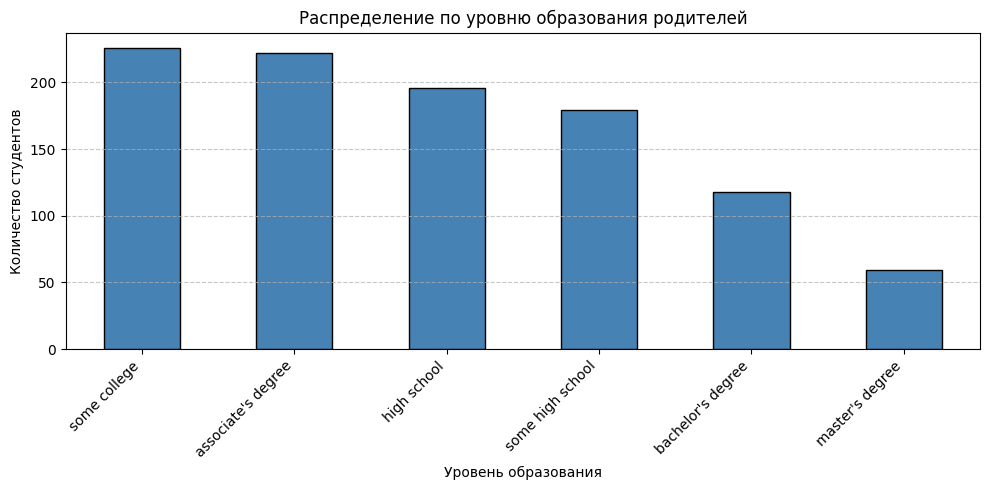

In [3]:
plt.figure(figsize=(10, 5))
df['parental level of education'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Распределение по уровню образования родителей')
plt.xlabel('Уровень образования')
plt.ylabel('Количество студентов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


1.2 Круговая диаграмма для race/ethnicity

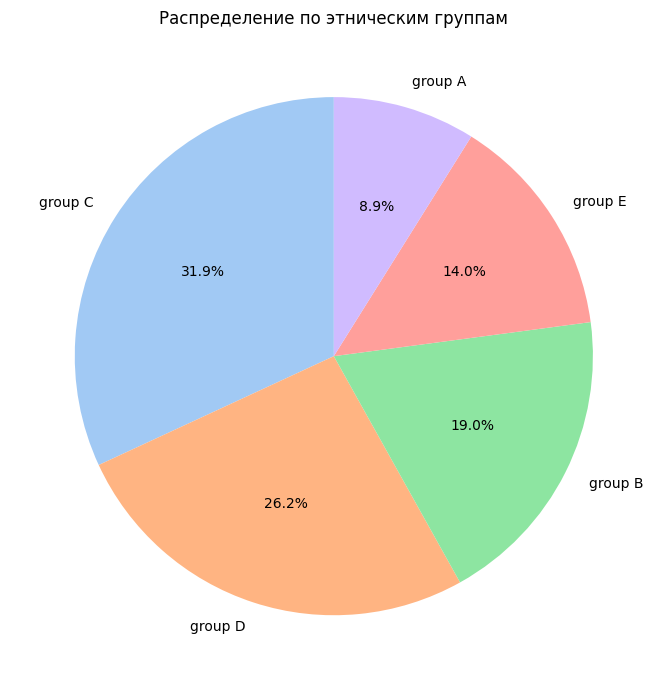

In [4]:
plt.figure(figsize=(7, 7))
df['race/ethnicity'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90,
                                         colors=sns.color_palette('pastel'))
plt.title('Распределение по этническим группам')
plt.ylabel('')  # убираем подпись оси Y
plt.tight_layout()
plt.show()

1.3 Гистограммы для всех числовых столбцов (на одном рисунке — один вызов функции)

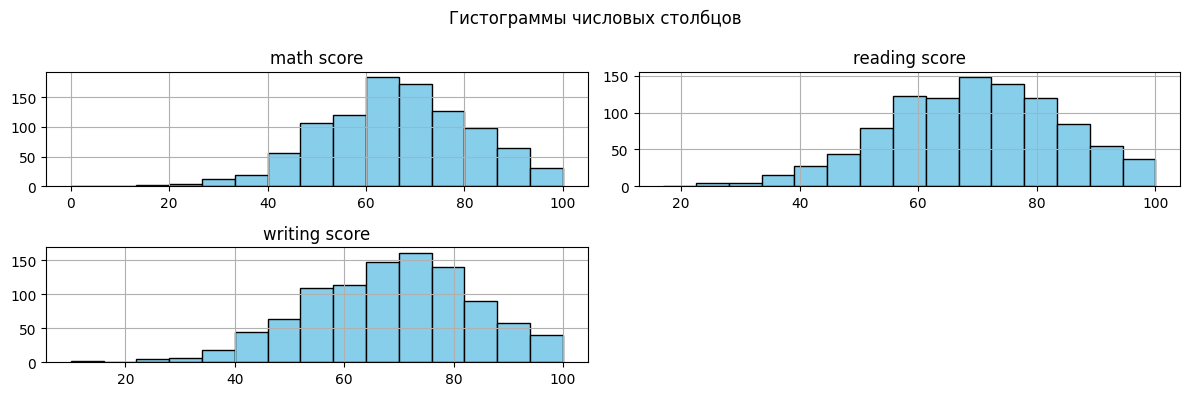

In [5]:
numeric_cols = ['math score', 'reading score', 'writing score']

df[numeric_cols].hist(figsize=(12, 4), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('Гистограммы числовых столбцов')
plt.tight_layout()
plt.show()

2. Matplotlib — subplots (3×2)

Создаём сетку 3 строки × 2 столбца (6 графиков, X = 1…6).


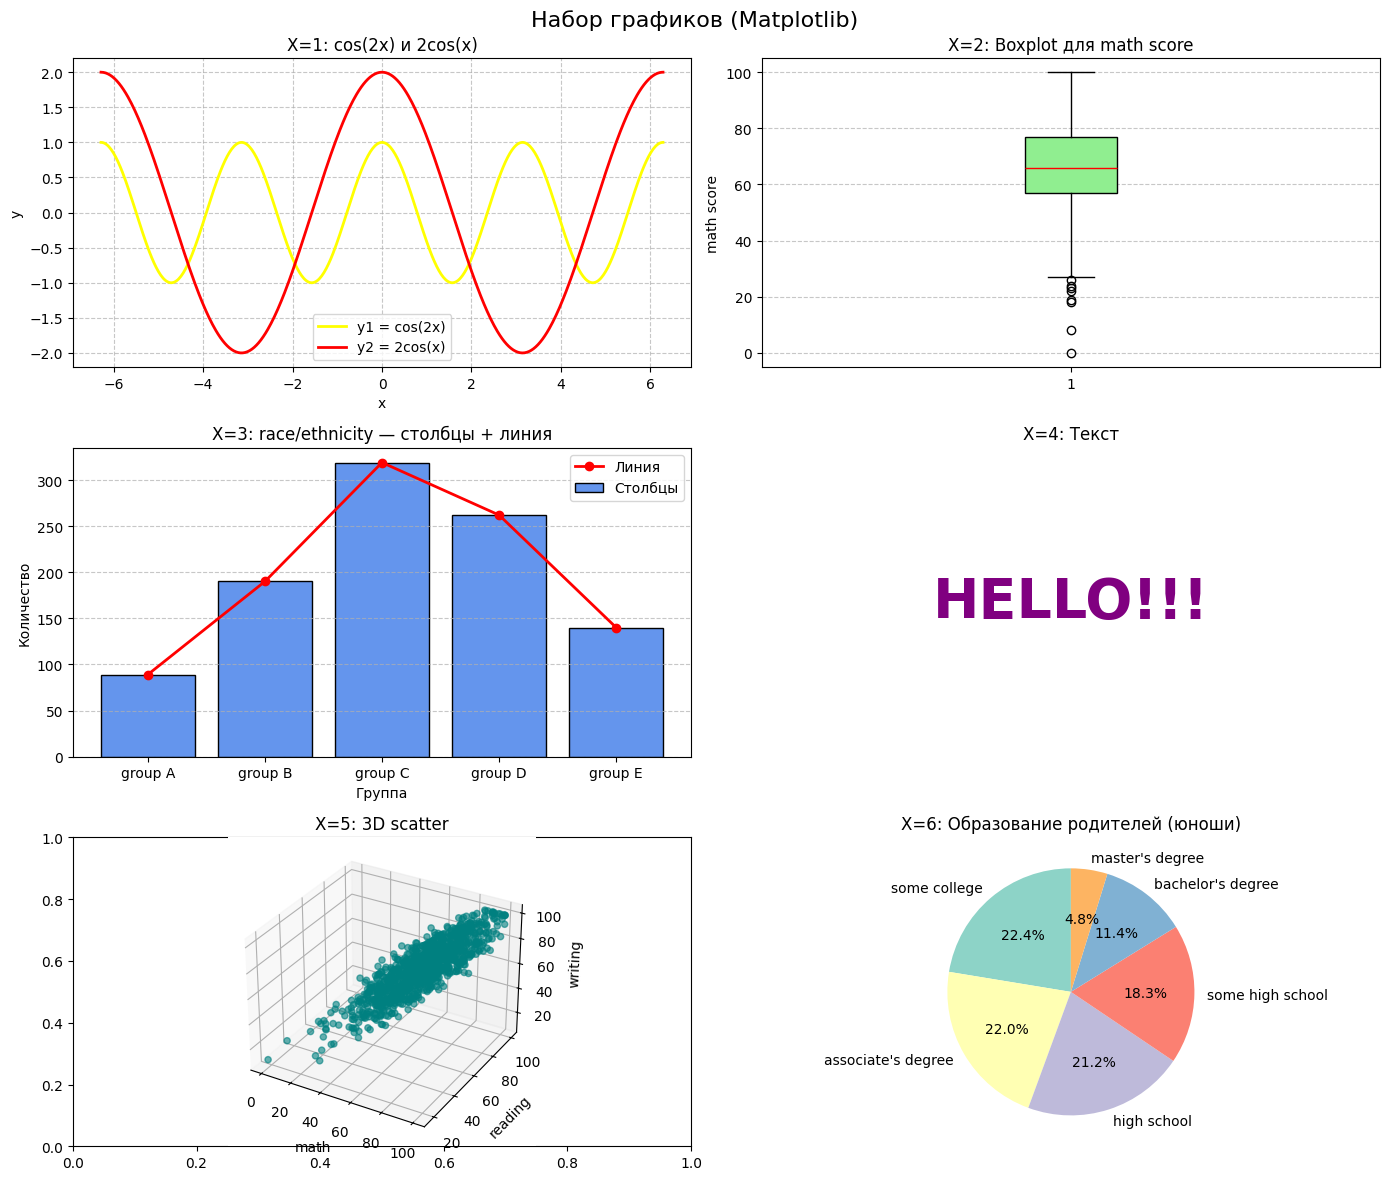

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Набор графиков (Matplotlib)', fontsize=16)

# ---------- X = 1: y1 = cos(2x), y2 = 2cos(x) ----------
x = np.linspace(-2 * np.pi, 2 * np.pi, 500)
y1 = np.cos(2 * x)
y2 = 2 * np.cos(x)

ax = axes[0, 0]
ax.plot(x, y1, color='yellow', linewidth=2, label='y1 = cos(2x)')
ax.plot(x, y2, color='red', linewidth=2, label='y2 = 2cos(x)')
ax.set_title('X=1: cos(2x) и 2cos(x)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

# ---------- X = 2: Ящик с усами для math score ----------
ax = axes[0, 1]
ax.boxplot(df['math score'].dropna(), patch_artist=True,
           boxprops=dict(facecolor='lightgreen', color='black'),
           medianprops=dict(color='red'))
ax.set_title('X=2: Boxplot для math score')
ax.set_ylabel('math score')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# ---------- X = 3: Комбинированный график для race/ethnicity ----------
ax = axes[1, 0]
counts = df['race/ethnicity'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='cornflowerblue', edgecolor='black', label='Столбцы')
ax.plot(counts.index, counts.values, color='red', marker='o', linewidth=2, label='Линия')
ax.set_title('X=3: race/ethnicity — столбцы + линия')
ax.set_xlabel('Группа')
ax.set_ylabel('Количество')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# ---------- X = 4: Текст HELLO!!! ----------
ax = axes[1, 1]
ax.text(0.5, 0.5, 'HELLO!!!', fontsize=40, ha='center', va='center',
        color='purple', fontweight='bold')
ax.set_title('X=4: Текст')
ax.axis('off')  # убираем оси

# ---------- X = 5: 3D-диаграмма рассеяния ----------
ax = fig.add_subplot(3, 2, 5, projection='3d')
ax.scatter(df['math score'], df['reading score'], df['writing score'],
           c='teal', marker='o', alpha=0.6)
ax.set_title('X=5: 3D scatter')
ax.set_xlabel('math')
ax.set_ylabel('reading')
ax.set_zlabel('writing')

# ---------- X = 6: Круговая диаграмма для parental level of education (только юноши) ----------
ax = axes[2, 1]
male_df = df[df['gender'] == 'male']   # в задании опечатка "mail" — имеется в виду male
male_counts = male_df['parental level of education'].value_counts()
ax.pie(male_counts.values, labels=male_counts.index, autopct='%1.1f%%',
       startangle=90, colors=sns.color_palette('Set3'))
ax.set_title('X=6: Образование родителей (юноши)')

plt.tight_layout()
plt.show()

Ответ на вопрос про выбросы (X=2):

Посмотрев на «ящик с усами» для math score, можно заметить точки ниже нижней границы (обычно это значения ниже ~25–30 баллов). Это выбросы — экстремально низкие оценки по математике. Формально их можно выделить так:

In [7]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['math score'] < lower) | (df['math score'] > upper)]
print(f'Выбросы: {len(outliers)}')
print(outliers[['gender', 'math score']])

Выбросы: 8
     gender  math score
17   female          18
59   female           0
145  female          22
338  female          24
466  female          26
787  female          19
842  female          23
980  female           8


3. Seaborn

3.1 pairplot (гистограммы по диагонали + scatter)

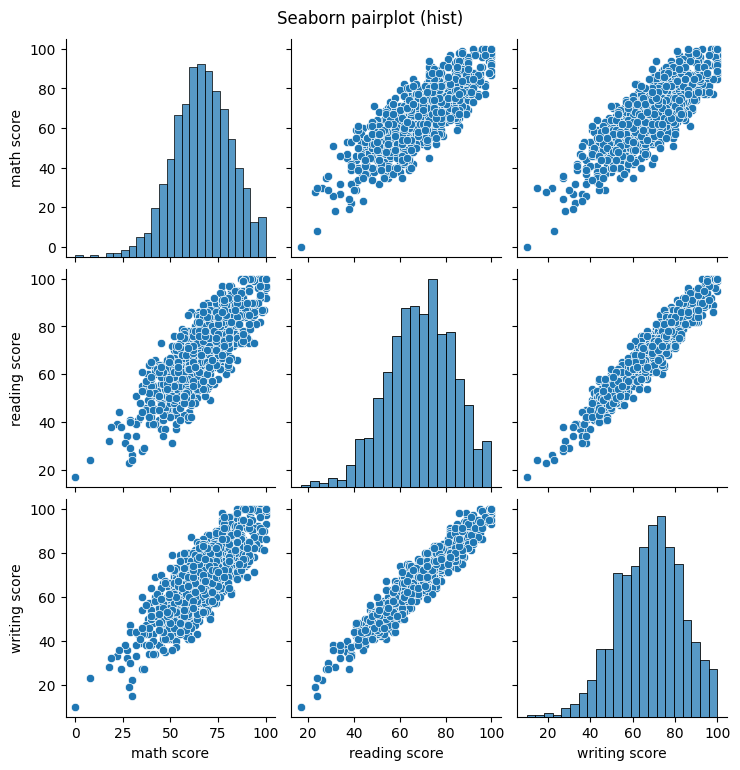

In [8]:
sns.pairplot(df[['math score', 'reading score', 'writing score']], diag_kind='hist')
plt.suptitle('Seaborn pairplot (hist)', y=1.02)
plt.show()

3.2 pairplot с kde по диагонали и hue='gender'

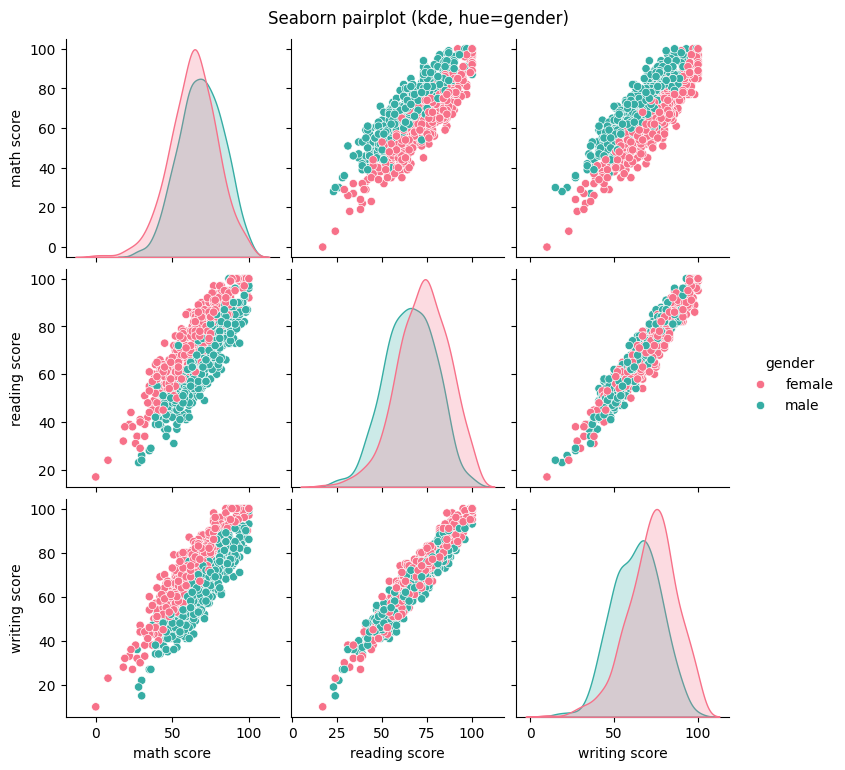

In [9]:
sns.pairplot(df[['math score', 'reading score', 'writing score', 'gender']],
             hue='gender', diag_kind='kde', palette='husl')
plt.suptitle('Seaborn pairplot (kde, hue=gender)', y=1.02)
plt.show()

3.3 Тепловая карта для числовых столбцов

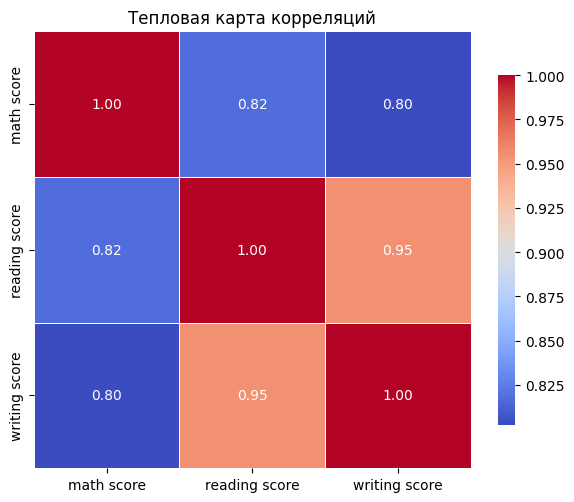

In [10]:
plt.figure(figsize=(6, 5))
corr = df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            square=True, cbar_kws={'shrink': .8})
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()